## Regression Diagnostic • Math 189 • Wi 2026
### Due Date: Tue, Jun 7

> Members: $\color{green}{\text{ Charlene Hsu, Beau Luc, Havyn Nguyen, Naomi Metzler    }}$
> 
>
> 

In [2]:
import numpy as np
import scipy
from scipy import stats as stats
import pandas as pd
from itertools import combinations

import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import acf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Diagnostics

The data and the first 5 rows of the data.

In [5]:
path = 'food_access_modeling.csv'
df_housing = pd.read_csv(path)

print(df_housing.head(5))

print(df_housing.shape[1])

   CensusTract    State          County  Urban urban_label  Pop2010  OHU2010  \
0   1001020100  Alabama  Autauga County      1       Urban     1912      693   
1   1001020200  Alabama  Autauga County      1       Urban     2170      743   
2   1001020300  Alabama  Autauga County      1       Urban     3373     1256   
3   1001020400  Alabama  Autauga County      1       Urban     4386     1722   
4   1001020500  Alabama  Autauga County      1       Urban    10766     4082   

   PovertyRate  MedianFamilyIncome  log_median_family_income  ...  \
0    11.336453             81250.0                 11.305286  ...   
1    17.876788             49000.0                 10.799576  ...   
2    15.046030             62609.0                 11.044664  ...   
3     2.845210             70607.0                 11.164885  ...   
4    15.150891             96334.0                 11.475577  ...   

   log_response  pct_children  pct_seniors  pct_white  pct_black  pct_asian  \
0      3.223299     26.51

### Fitting the model to a full model

In [30]:
response = 'pct_low_income_low_access'
covariate = "pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle + Urban + pct_children + pct_seniors + pct_black + pct_hispanic + pct_asian"
full_formula = response + " ~ " + covariate
print("full_formula: ",full_formula)
full_model = smf.ols(full_formula,data=df_housing).fit()

full_model.summary()

full_formula:  pct_low_income_low_access ~ pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle + Urban + pct_children + pct_seniors + pct_black + pct_hispanic + pct_asian


<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     pct_low_income_low_access   R-squared:                       0.195
Model:                                   OLS   Adj. R-squared:                  0.195
Method:                        Least Squares   F-statistic:                     1022.
Date:                       Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                               10:49:37   Log-Likelihood:            -1.6394e+05
No. Observations:                      42156   AIC:                         3.279e+05
Df Residuals:                          42145   BIC:                         3.280e+05
Df Model:                                 10                                         
Covariance Type:                   nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   80.5962      2.954     27.287      0.000      74.807      86.385
pct_snap                     0.0279      0.011      2.486      0.013       0.006       0.050
PovertyRate                  0.2540      0.010     24.435      0.000       0.234       0.274
log_median_family_income    -7.3335      0.254    -28.852      0.000      -7.832      -6.835
pct_no_vehicle              -0.2196      0.012    -18.094      0.000      -0.243      -0.196
Urban                        5.2818      0.168     31.496      0.000       4.953       5.610
pct_children                 0.1925      0.013     14.610      0.000       0.167       0.218
pct_seniors                  0.0727      0.010      7.452      0.000       0.054       0.092
pct_black                    0.0308      0.003      8.794      0.000       0.024       0.038
pct_hispanic                -0.0493      0.004    -12.900      0.000      -0.057      -0.042
pct_asian                   -0.0982      0.010    -10.125      0.000      -0.117      -0.079
==============================================================================
Omnibus:                     9774.425   Durbin-Watson:                   1.636
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            24609.872
Skew:                           1.272   Prob(JB):                         0.00
Kurtosis:                       5.746   Cond. No.                     2.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Model Diagnosis 

The 5 different things we need to check:
* Independence: $\epsilon_1 ... \epsilon_n$ are independent
* Identical / homoscedasticity: The errors have constant variance, i.e., $\epsilon_1 ... \epsilon_n$ are $N(0,r^2)$
* Normally distributed (Normality): $\epsilon_1 ... \epsilon_n$ are $\underset{=}{N}(0,r^2)$
* Linearity: The relationship between the independent variables and the response is linear $y_i = B_0 + B_1 x_i$
* Multicollinearity: The Case where two or more covariates are highly correlated. 

### Identical/homoscedasticity and Linearity

We check whether the error have constant variance for homoscedasticity. Additionally, we check if the residuals are randomly scattered around 0 then the assumption of linearity is satisfied.

Analysis: Both conditions are not reached as we can see linearity isn't true as it centers at a different value.

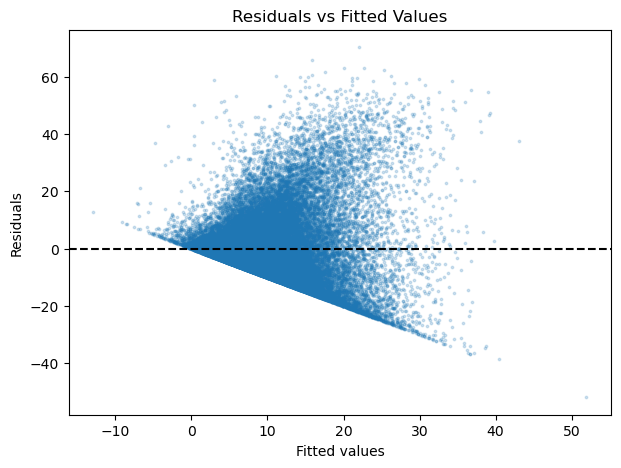

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(full_model.fittedvalues, full_model.resid, s=3, alpha=0.2)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

### Normally distributed

We check whether the model residuals look normal. 

Analysis: We can see that the plot is right skewed and the tail shift away from our expected linear condition. Thus, we don't reach the normality condition.

<Figure size 700x500 with 0 Axes>

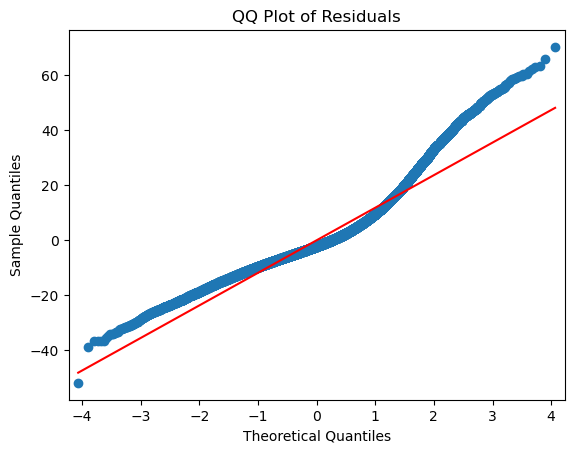

In [12]:
plt.figure(figsize=(7, 5))
sm.qqplot(full_model.resid, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

### Multicollinearity

We can see that the covariates are nearly highly correlated. This is the case with pct_snap and pct_no_vehicles. Alongside pct_black with pct_snap, pct_no_vehicle,and poverty rate. The VIF aren't >5 but VIF for pct_snap is 4.477 so multicollinearity is still a risk.

['pct_snap', 'PovertyRate', 'log_median_family_income', 'pct_no_vehicle', 'Urban', 'pct_children', 'pct_seniors', 'pct_black', 'pct_hispanic', 'pct_asian']
VIF: pct_snap:  4.477
VIF: PovertyRate:  3.980
VIF: log_median_family_income:  4.015
VIF: pct_no_vehicle:  2.185
VIF: Urban:  1.219
VIF: pct_children:  1.852
VIF: pct_seniors:  1.694
VIF: pct_black:  1.583
VIF: pct_hispanic:  1.357
VIF: pct_asian:  1.226


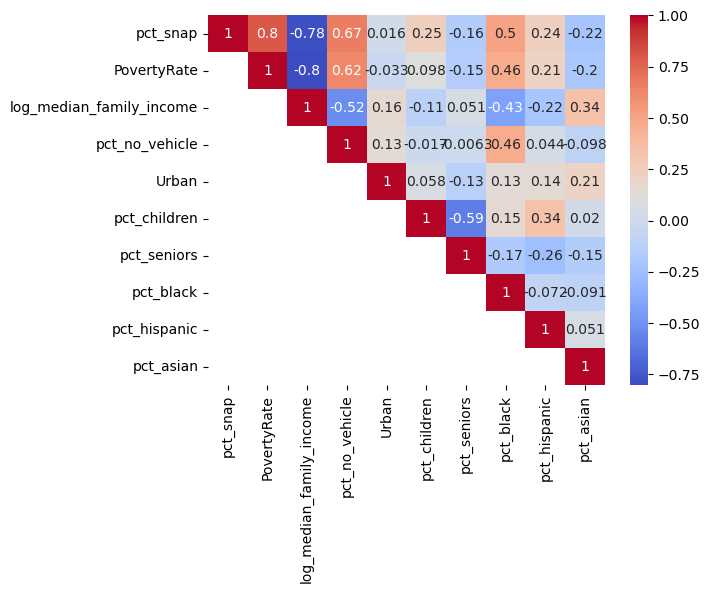

In [31]:
covariates_term = ['pct_snap','PovertyRate','log_median_family_income','pct_no_vehicle','Urban','pct_children','pct_seniors','pct_black','pct_hispanic','pct_asian']
print(covariates_term)
corr_table = df_housing[covariates_term].corr() 
sns.heatmap(corr_table, annot=True, cmap='coolwarm', mask=np.tril(corr_table, k=-1))

exog = full_model.model.exog
names = full_model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

### Fitted Model to interaction model

Thus, we should changed our model such that model doesn't have issues with homoscedasticity, normality, linearity,and multicollinearity. We changed the formula so pct_snap:Urban and pct_no_vehicle:Urban are interaction terms. We also remove the pct_children, pct_seniors , pct_black, pct_hispanic, and pct_asian covariate terms.

In [28]:
response = 'pct_low_income_low_access'
covariate = "pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle + Urban + pct_snap:Urban + pct_no_vehicle:Urban"
full_formula = response + " ~ " + covariate
print("full_formula: ",full_formula)
full_model = smf.ols(full_formula,data=df_housing).fit()

full_model.summary()

full_formula:  pct_low_income_low_access ~ pct_snap + PovertyRate + log_median_family_income + pct_no_vehicle + Urban + pct_snap:Urban + pct_no_vehicle:Urban


<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     pct_low_income_low_access   R-squared:                       0.188
Model:                                   OLS   Adj. R-squared:                  0.188
Method:                        Least Squares   F-statistic:                     1391.
Date:                       Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                               10:25:00   Log-Likelihood:            -1.6413e+05
No. Observations:                      42156   AIC:                         3.283e+05
Df Residuals:                          42148   BIC:                         3.284e+05
Df Model:                                  7                                         
Covariance Type:                   nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   89.3638      2.799     31.926      0.000      83.878      94.850
pct_snap                    -0.1976      0.023     -8.525      0.000      -0.243      -0.152
PovertyRate                  0.2237      0.010     22.028      0.000       0.204       0.244
log_median_family_income    -7.5742      0.244    -31.009      0.000      -8.053      -7.095
pct_no_vehicle               0.3275      0.040      8.243      0.000       0.250       0.405
Urban                        3.8118      0.289     13.187      0.000       3.245       4.378
pct_snap:Urban               0.3130      0.024     13.289      0.000       0.267       0.359
pct_no_vehicle:Urban        -0.5877      0.041    -14.199      0.000      -0.669      -0.507
==============================================================================
Omnibus:                     9514.161   Durbin-Watson:                   1.629
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            23295.967
Skew:                           1.251   Prob(JB):                         0.00
Kurtosis:                       5.647   Cond. No.                     1.52e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.52e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

---